In [1]:
import numpy as np
import pandas as pd
import scipy.linalg as sla
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [36]:
class MyLinearRegression:
  def __init__(self):
    self.w = None
  def fit(self,X,y):
    X = np.array(X)
    y = np.array(y)
    assert len(y.shape) == 1 and len(X.shape)==2
    assert X.shape[0] == y.shape[0]
    y = y[:, np.newaxis]
    l,n=X.shape
    X_train = np.hstack((X, np.ones((l,1))))
    self.w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y
    return self
  def predict(self,X):
    l,n=X.shape
    X_train = np.hstack((X, np.ones((l,1))))
    y_pred = X_train @ self.w
    return y_pred
  def get_weights(self):
    return self.w.copy()

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
def linear_expression(x):
  return 5*x+6

In [31]:
obj_num = 50
X = np.linspace(-5,5,obj_num)
y= linear_expression(X) + np.random.randn(obj_num)*5
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size = 0.5)


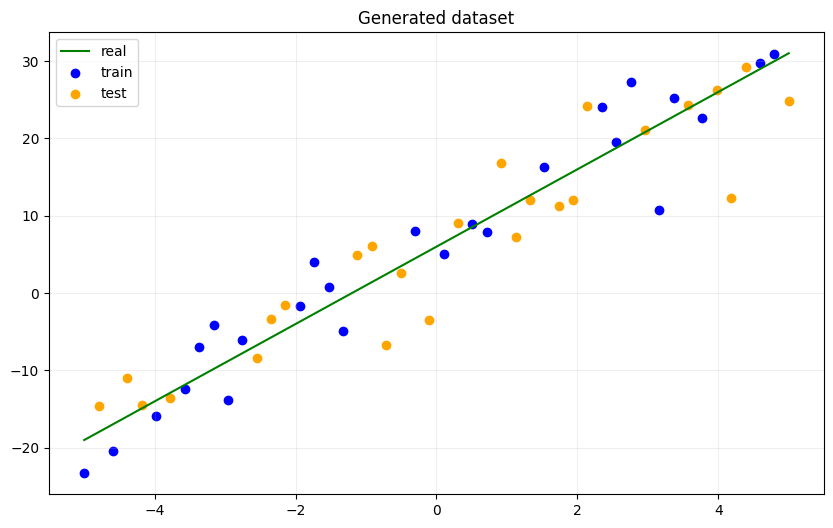

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(X, linear_expression(X), label='real', c='g')
plt.scatter(X_train, y_train, label='train', c='b')
plt.scatter(X_test, y_test, label='test', c='orange')

plt.title("Generated dataset")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [37]:
regressor = MyLinearRegression()

regressor.fit(X_train[:, np.newaxis], y_train)

predictions = regressor.predict(X_test[:, np.newaxis])
w = regressor.get_weights()
w

array([[5.12262789],
       [6.50156427]])

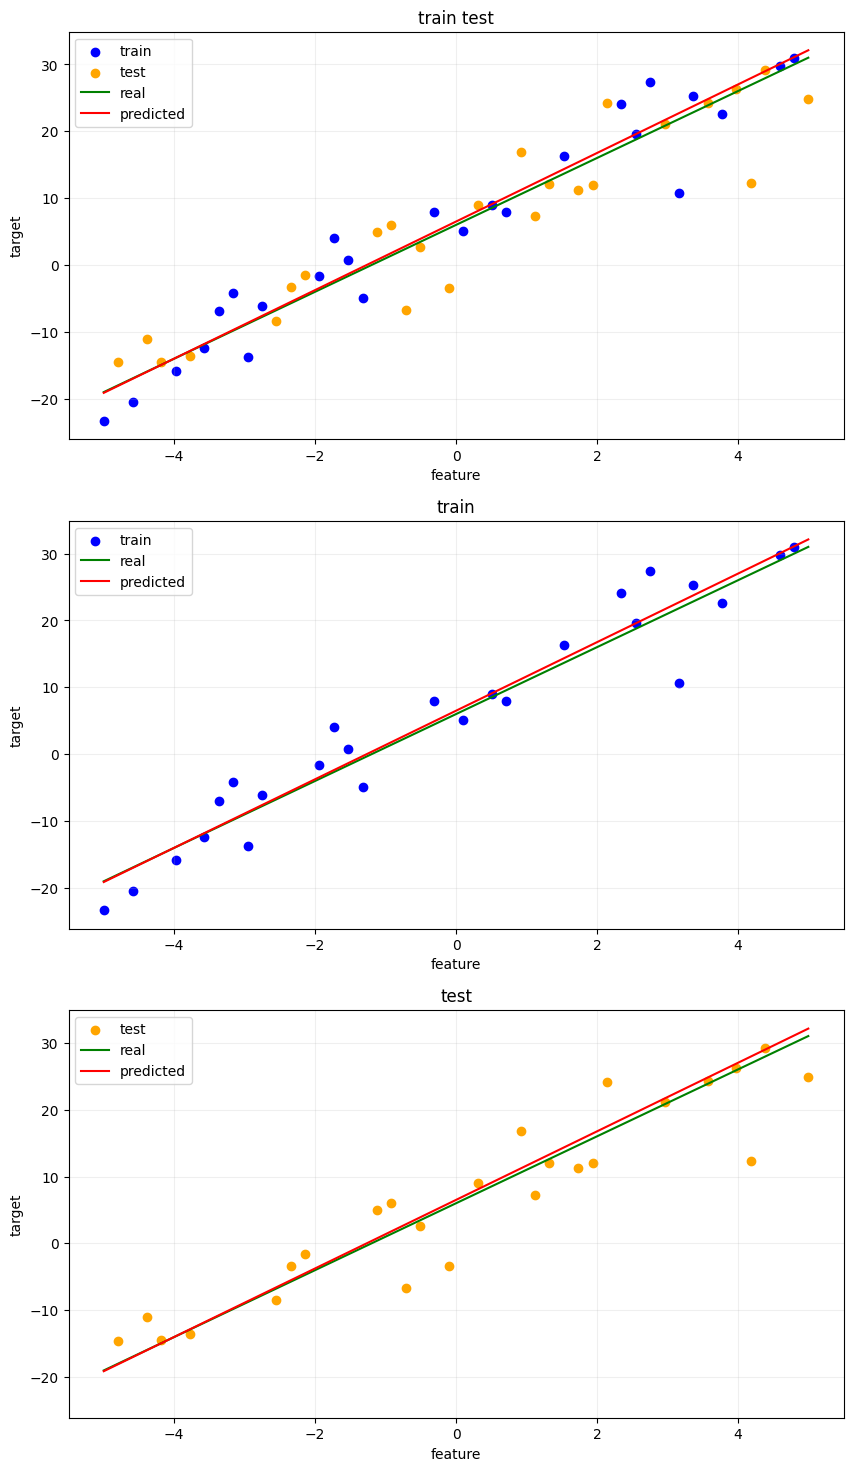

In [38]:
plt.figure(figsize=(10, 18))

ax = None

for i, types in enumerate([['train', 'test'], ['train'], ['test']]):
    ax = plt.subplot(3, 1, i + 1, sharey=ax)
    if 'train' in types:
        plt.scatter(X_train, y_train, label='train', c='b')
    if 'test' in types:
        plt.scatter(X_test, y_test, label='test', c='orange')

    plt.plot(X, linear_expression(X), label='real', c='g')
    plt.plot(X, regressor.predict(X[:, np.newaxis]), label='predicted', c='r')

    plt.ylabel('target')
    plt.xlabel('feature')
    plt.title(" ".join(types))
    plt.grid(alpha=0.2)
    plt.legend()

plt.show()

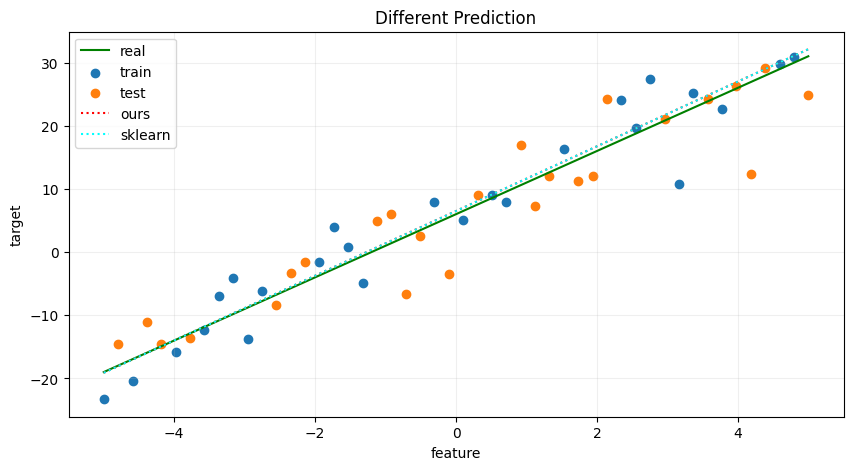

In [39]:
sk_reg = LinearRegression().fit(X_train[:, np.newaxis], y_train)
plt.figure(figsize=(10, 5))
plt.plot(X, linear_expression(X), label='real', c='g')

plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.plot(X, regressor.predict(X[:, np.newaxis]), label='ours', c='r', linestyle=':')
plt.plot(X, sk_reg.predict(X[:, np.newaxis]), label='sklearn', c='cyan', linestyle=':')

plt.title("Different Prediction")
plt.ylabel('target')
plt.xlabel('feature')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [40]:
sk_reg.coef_, sk_reg.intercept_

(array([5.12262789]), np.float64(6.501564274837006))

In [41]:
from sklearn.metrics import mean_squared_error

train_predictions = regressor.predict(X_train[:, np.newaxis])
test_predictions = regressor.predict(X_test[:, np.newaxis])

print('Train MSE: ', mean_squared_error(y_train, train_predictions))
print('Test MSE: ', mean_squared_error(y_test, test_predictions))

Train MSE:  17.260368937149593
Test MSE:  28.41346938459828


In [43]:
class MyGradientLinearRegression(MyLinearRegression):
    def __init__(self, **kwargs):
        super().__init__(**kwargs) # передает именные параметры родительскому конструктору

    def fit(self, X, y, lr=0.01, max_iter=100):
        # Принимает на вход X, y и вычисляет веса по данной выборке
        # Не забудьте про фиктивный признак равный 1
        X = np.array(X)
        y = np.array(y)
        assert len(y.shape) == 1 and len(X.shape) == 2
        assert X.shape[0] == y.shape[0]

        y = y[:, np.newaxis]
        l, n = X.shape

        # Добавляем признак из единиц
        X_train = np.hstack((X, np.ones((l, 1))))  # [l, n+1]

        self.w = np.random.randn(n + 1, 1)

        self.losses = []

        for iter_num in range(max_iter):
            y_pred = self.predict(X)
            self.losses.append(mean_squared_error(y, y_pred))

            grad = self._calc_gradient(X_train, y, y_pred)

            assert grad.shape == self.w.shape, \
            f"gradient shape {grad.shape} is not equal weight shape {self.w.shape}"

            self.w -= lr * grad

        return self
    def _calc_gradient(self, X, y, y_pred):
        grad = (2. / X.shape[0]) * (X.T @ (y_pred - y))

        return grad
    def get_losses(self):
        return self.losses

In [44]:
regressor = MyGradientLinearRegression()

l = regressor.fit(X_train[:, np.newaxis], y_train, max_iter=100).get_losses()

predictions = regressor.predict(X_test[:, np.newaxis])
w = regressor.get_weights()

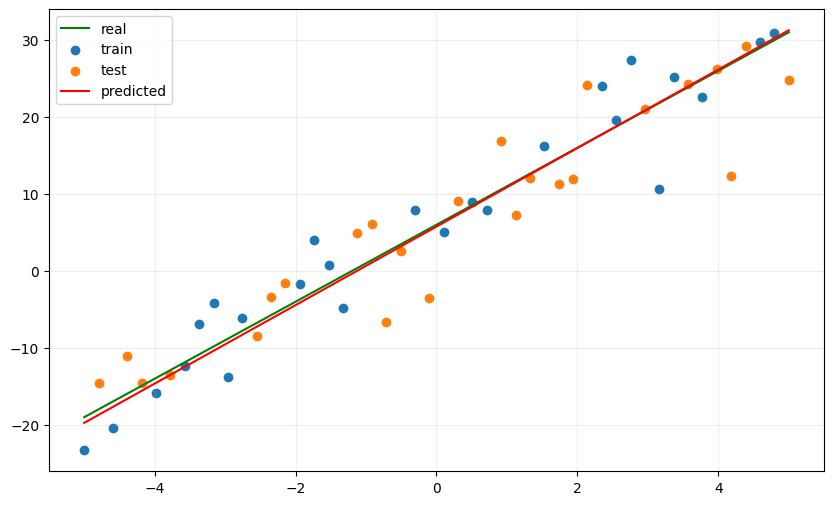

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(X, linear_expression(X), label='real', c='g')

plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.plot(X, regressor.predict(X[:, np.newaxis]), label='predicted', c='r')

plt.grid(alpha=0.2)
plt.legend()
plt.show()

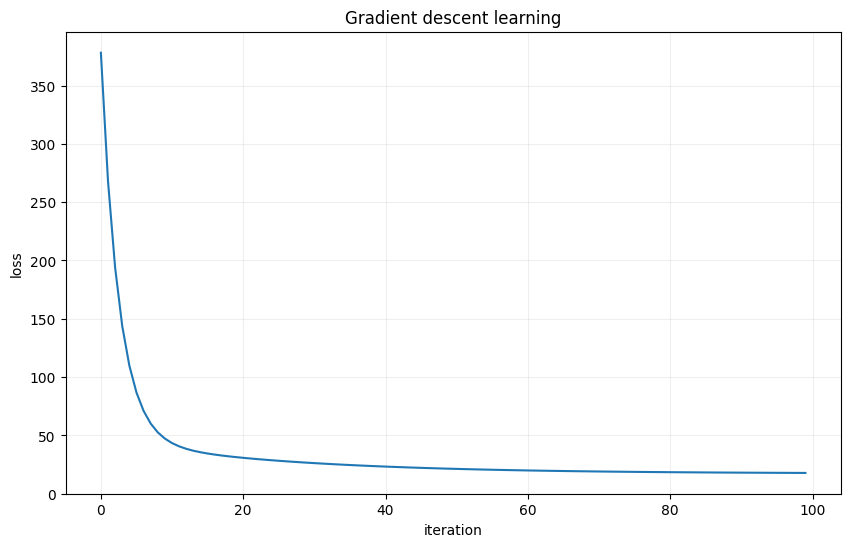

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(l)

plt.title('Gradient descent learning')
plt.ylabel('loss')
plt.xlabel('iteration')
plt.ylim(bottom=0)
plt.grid(alpha=0.2)

plt.show()